# Feature Attribution using Ranking - v1.4

In [1]:
import sys

!{sys.executable} -m pip install xgboost
!{sys.executable} -m pip install catboost
!{sys.executable} -m pip install nbimporter
!{sys.executable} -m pip install tensorflow

In [2]:
import time
import numpy as np
import pandas as pd
import zipfile as zf
import nbimporter

import sklearn.ensemble
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb
from catboost import CatBoostClassifier

from scipy.sparse.linalg import eigs

import networkx as nx
import GraphPR as gpr
import PageRank as pr

# Data preprocessing methods

In [3]:
# return one df without nan's on num_cols
# numerical features: fill nan's with median/mean/mode/zeros

def pre_proc_fillna_num_fts(df,num_cols,num_type='mean'):
    df_train= df.copy()

    if(num_type=='median'):
        for col in num_cols:
            ft_median= df_train[col].median()
            df_train[col]= df_train[col].fillna(ft_median)
    elif(num_type=='mode'):
        for col in num_cols:
            ft_mode= df_train[col].value_counts().index[0]
            df_train[col]= df_train[col].fillna(ft_mode)
    elif(num_type=='zeros'):
        for col in num_cols:
            ft_zero= 0
            df_train[col]= df_train[col].fillna(ft_zero)
    else:
        for col in num_cols:
            ft_mean= df_train[col].mean()
            df_train[col]= df_train[col].fillna(ft_mean)

    return df_train

In [4]:
# return one df without nan's on cat_cols
# categorical features: fill nan's with mode/mean/median/zeros

def pre_proc_fillna_cat_fts(df,cat_cols,cat_type='mode'):
    df_train= df.copy()
    
    if(cat_type!='mode' and type(df_train[cat_cols[0]].value_counts().index[0])!=type('str')):
        if(cat_type=='mean'):
            for col in cat_cols:
                ft_mean= df_train[col].mean()
                df_train[col]= df_train[col].fillna(ft_mean)
        elif(cat_type=='median'):
            for col in cat_cols:
                ft_median= df_train[col].median()
                df_train[col]= df_train[col].fillna(ft_median)
        elif(cat_type=='zeros'):
            for col in num_cols:
                ft_zero= 0
                df_train[col]= df_train[col].fillna(ft_zero)
    else:
        for col in cat_cols:
            ft_mode= df_train[col].value_counts().index[0]
            df_train[col]= df_train[col].fillna(ft_mode)

    return df_train

In [5]:
# selected_cols refers only to df's columns with numerical values
# if selected_cols is not defined as argument, all df columns will be normalized

def normalize_selected(df, selected_cols=[]):
    result= df.copy()
    
    if (len(selected_cols)== 0):
        selected_cols= df.columns
    
    for col in selected_cols:
        max_value= df[col].max()
        min_value= df[col].min()
        result[col]= (df[col]- min_value)/ (max_value - min_value)
        
    return result

In [6]:
# return a sorted DataFrame with Features and Importances - OHE compacted, that is, dataset's original features

def ft_importance_df(importances, ft_names, replace_list):
    fti= pd.Series(importances, index=ft_names).sort_values(ascending=False).to_frame().reset_index()
    fti= fti.rename(columns= {'index':'Feature',0:'Importance'}, inplace=False)
    fti['Feature'].replace(replace_list, inplace=True)
    fti= fti.groupby(['Feature']).sum().sort_values('Importance', ascending=False).reset_index()
    
    return fti

# Feature Attribution using Ranking - methods

In [7]:
# return a DataFrame with replaced values (mean/median/mode/zeros/none to categorical and numeric) 
# to fill train cols. df is post-processed (cat_cols encoded)

def replace_values(df,num_cols,num_type='mean',cat_type='none'):
    cat_values= None
    num_values= None
    
    if (cat_type=='mean'):
        cat_values= df.mean(axis=0).to_frame().T
    elif (cat_type=='median'):
        cat_values= df.median(axis=0).to_frame().T
    elif (cat_type=='mode'):
        cat_values= df.mode(axis=0)
    elif (cat_type=='zeros'):
        cat_values= df.loc[0:0,:].copy()
        cat_values.loc[:,:]= 0
    
    if (num_type=='mode'):
        num_values= df.mode(axis=0)
    elif (num_type=='median'):
        num_values= df.median(axis=0).to_frame().T
    elif (num_type=='mean'):
        num_values= df.mean(axis=0).to_frame().T
    elif (num_type=='zeros'):
        num_values= df.loc[0:0,:].copy()
        num_values.loc[:,:]= 0

    if(cat_type!='none'):
        cat_values[num_cols]= num_values[num_cols]
        return cat_values
    
    return num_values

In [8]:
# train the ML model and return its mean accuracy after n_train runs

def train_model_get_acc_mean(model, x_trn, x_tst, y_trn, y_tst, n_train):
    trainings= []
    
    np_ar= np.ndarray((0,0))    # model.fit() expect a 1d array instead of a pd.DataFrame
    pd_df= pd.DataFrame(np_ar)  # we need to verify and change it using values.ravel()
    
    if (type(y_trn)== type(pd_df)):
        
        for i in range(n_train):

            model.fit(x_trn, y_trn.values.ravel())
            acc= sklearn.metrics.accuracy_score(y_tst, model.predict(x_tst))

            trainings.append(acc)
    else:
        for i in range(n_train):

            model.fit(x_trn, y_trn)
            acc= sklearn.metrics.accuracy_score(y_tst, model.predict(x_tst))

            trainings.append(acc)
            
    return np.mean(trainings)

In [446]:
# re-training is needed because machine learning models typically assume that the train and the test data comes from a similar distribution 
# (Hooker et al., 2018)

# model is a NO trained model

# here we return p(x|i) and p(x|ij)
def remove_and_retrain(model, replace_ft_vals, x_trn, x_tst, y_trn, y_tst, n_train, verbose=False):
    acc_no_i= []
    acc_no_ij= []

    n_fts= len(x_trn.columns)

    start= time.time()

    for i in range(n_fts):
        acc_row= []

        # replace the i-th ft with its respective mode/mean to "remove" it. train the ML model and get the mean accuracy
        train_copy_no_i= x_trn.copy()
        train_copy_no_i.loc[:,train_copy_no_i.columns[i]]= replace_ft_vals.iloc[0,i]

        acc_no_i.append(train_model_get_acc_mean(model, train_copy_no_i, x_tst, y_trn, y_tst, n_train))

        for j in range(n_fts):

            if (i<= j):
                # replace the j-th ft with its respective mode/mean to "remove" it. here, we "remove" the i-th and the j-th ft
                # train the ML model and get the mean accuracy
                train_copy_no_ij= train_copy_no_i.copy()
                train_copy_no_ij.loc[:,train_copy_no_ij.columns[j]]= replace_ft_vals.iloc[0,j]

                acc_row.append(train_model_get_acc_mean(model, train_copy_no_ij, x_tst, y_trn, y_tst, n_train))
            elif (i> j):
                acc_row.append(acc_no_ij[j][i])

        acc_no_ij.append(acc_row)

    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))

    return acc_no_i, acc_no_ij

In [447]:
# remove WITH NO retraining - to speedup and stability improvements
# model is a TRAINED model

# here we return p(x|i) and p(x|ij)
def remove_and_return_costs(model, replace_ft_vals, x_tst, y_tst, verbose=False):
    acc_no_i= []
    acc_no_ij= []

    n_fts= len(x_tst.columns)

    start= time.time()
    
    np_ar= np.ndarray((0,0))    # model.fit() expect a 1d array instead of a pd.DataFrame
    pd_df= pd.DataFrame(np_ar)  # we need to verify and change it using values.ravel()
    

    for i in range(n_fts):  # remove and predict process to get gains/losses
        acc_row= []

        # replace the i-th ft of test set with its respective mode/mean to "remove" it. 
        x_tst_copy_no_i= x_tst.copy()
        x_tst_copy_no_i.loc[:,x_tst_copy_no_i.columns[i]]= replace_ft_vals.iloc[0,i]

        acc_no_i.append(sklearn.metrics.accuracy_score(y_tst, model.predict(x_tst_copy_no_i)))

        for j in range(n_fts):

            if (i<= j):
                # replace the j-th ft of test with its respective mode/mean to "remove" it. 
                # here, we "remove" the i-th and the j-th ft
                # test the ML model and get the mean accuracy
                x_tst_copy_no_ij= x_tst_copy_no_i.copy()
                x_tst_copy_no_ij.loc[:,x_tst_copy_no_ij.columns[j]]= replace_ft_vals.iloc[0,j]

                acc_row.append(sklearn.metrics.accuracy_score(y_tst, model.predict(x_tst_copy_no_ij)))
            elif (i> j):
                acc_row.append(acc_no_ij[j][i])

        acc_no_ij.append(acc_row)

    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))

    return acc_no_i, acc_no_ij

In [11]:
import math
from sklearn.neighbors import NearestNeighbors

# find the test_size nearest neighbors from a target_x instance
# return train, test, labels_train, labels_test datsets based on knn
# target_x and target_y are into testX and testY

def knn_train_test_split(df_x, df_y, target_x, target_y, test_size= 0.2):
    
    m_ins= df_x.shape[0] # m x n dataset

    neighbors= math.floor(test_size* m_ins)

    knn= NearestNeighbors(n_neighbors= neighbors)
    knn.fit(df_x)

    knn_index= knn.kneighbors(target_x, return_distance=False)
    
    trainX= df_x.drop(df_x.index[knn_index[0]])
    trainY= df_y.drop(df_y.index[knn_index[0]])

    testX= df_x.loc[df_x.index[knn_index[0]]]
    testY= df_y.loc[df_y.index[knn_index[0]]]

    testX= pd.concat([target_x, testX])
    testY= pd.concat([target_y, testY])
    
    return trainX, testX, trainY, testY

In [12]:
# find the neighb_size nearest neighbors from a target_x instance
# return data and target datsets based on knn
# with target_x and target_y into x_fts and y_trg

def knn_neighborhood(df_x, df_y, target_x, target_y, neighb_size= 0.2, target_in= True):
    
    m_ins= df_x.shape[0] # m x n dataset

    neighbors= math.floor(neighb_size* m_ins)

    knn= NearestNeighbors(n_neighbors= neighbors)
    knn.fit(df_x)

    knn_index= knn.kneighbors(target_x, return_distance=False)

    x_fts= df_x.loc[df_x.index[knn_index[0]]]
    y_trg= df_y.loc[df_y.index[knn_index[0]]]

    if (target_in== True):
        x_fts= pd.concat([target_x, x_fts])
        y_trg= pd.concat([target_y, y_trg])
    
    return x_fts, y_trg

In [13]:
# df_x and df_y doesn't contain target_x and target_y
# model is a a TRAINED model

# here we return p(x|i) and p(x|ij)
def knn_remove_and_return_costs(model, replace_ft_vals, x_tst, y_tst, target_x, target_y, 
                                neighb_size=0.01, verbose=False):
    
    start= time.time()

    m_ins= x_tst.shape[0] # m x n dataset
    n_fts= x_tst.shape[1]
    
    k_viz= math.floor(neighb_size* m_ins)
    k_viz_aux= math.floor(np.sqrt(m_ins))
    
    if (k_viz< k_viz_aux):
        k_viz= k_viz_aux
        
    # here, we generate a neighborhood of the target instance
    x_neighb, y_neighb= knn_neighborhood(x_tst, y_tst, target_x, target_y, neighb_size= (k_viz/ m_ins))    

    acc_no_i, acc_no_ij= remove_and_return_costs(model, replace_ft_vals, x_neighb, y_neighb)
    
    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))
    
    return acc_no_i, acc_no_ij

In [14]:
from sklearn.model_selection import KFold, StratifiedKFold

# df_x and df_y doesn't contain target_x and target_y
# model is a a TRAINED model

# here we return p(x|i) and p(x|ij)
def knnfold_remove_and_return_costs(model, replace_ft_vals, x_tst, y_tst, target_x, target_y, 
                                neighb_size=0.01, k_folds=5, verbose=False):
    
    start= time.time()

    m_ins= x_tst.shape[0] # m x n dataset
    n_fts= x_tst.shape[1]
    
    k_viz= math.floor(neighb_size* m_ins)
    k_viz_aux= math.floor(np.sqrt(m_ins))
    
    if (k_viz< k_viz_aux):
        k_viz= k_viz_aux
        
    # here, we generate a neighborhood of the target instance
    x_neighb, y_neighb= knn_neighborhood(x_tst, y_tst, target_x, target_y, 
                                         neighb_size= (k_viz/ m_ins), target_in= False) 
    

    K_folds= math.floor(np.sqrt(n_fts))

    if (K_folds< 5):
        K_folds= 5
        
    if (K_folds< k_folds):
        K_folds= k_folds   

    skf= StratifiedKFold(n_splits= K_folds, random_state=1234, shuffle=True)    
        
    acc_no_i= np.zeros(n_fts)
    acc_no_ij= np.zeros((n_fts,n_fts))
    
    for train_index, test_index in skf.split(x_neighb, y_neighb):
    
        x_fold= x_neighb.iloc[train_index]
        y_fold= y_neighb.iloc[train_index]
        
        # add the target instance on the fold set
        x_fold.append(target_x)
        y_fold.append(target_y)
    
        aux_acc_no_i, aux_acc_no_ij= remove_and_return_costs(model, replace_ft_vals, x_fold, y_fold)
    
        acc_no_i += aux_acc_no_i
        acc_no_ij += aux_acc_no_ij

    
    acc_no_i /= K_folds
    acc_no_ij /= K_folds
    
    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))
    
    return acc_no_i, acc_no_ij

# Costs matrix methods

In [448]:
# here we return | p(x|ij) - p(x|j) |

def get_p_matrix_v2(n_fts, no_j, no_ij):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        for j in range(n_fts):
            
            pj= no_j[j]
            pij= no_ij[i][j]

            p_matrix[i][j]= np.abs(pij- pj)
                
    return p_matrix

In [449]:
# here we return (| p(x|ij) - p(x|j) | + | p(x|i) - p(x) |) / 2

def get_p_matrix_v3(n_fts, all_fts, no_i, no_j, no_ij):
    p_matrix= np.zeros((n_fts, n_fts))
    p= all_fts

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pj= no_j[j]
            pij= no_ij[i][j]

            p_matrix[i][j]= (np.abs(pij- pj)+ np.abs(pi- p))/ 2
                
    return p_matrix

In [450]:
# here we return (| p(x|ij) - p(x|i) | + | p(x|j) - p(x) |) / 2

def get_p_matrix_v4(n_fts, all_fts, no_i, no_j, no_ij):
    p_matrix= np.zeros((n_fts, n_fts))
    p= all_fts

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pj= no_j[j]
            pij= no_ij[i][j]

            p_matrix[i][j]= (np.abs(pij- pi)+ np.abs(pj- p))/ 2
                
    return p_matrix

# Stationary distribution methods

In [451]:
# the stationary distribution is the fraction of time that the system spends in each state as the 
# number of samples approaches infinity
# it looks like there's not a built-in method to find the stationary distribution

# converts a matrix to a row stochastic matrix - a real square matrix, with each row summing to 1
def to_row_stochastic_matrix(M):
    result= M.copy()
    
    for row in result:
        n= sum(row)
        if n> 0:
            row[:]= [f/sum(row) for f in row]
    
    return result

In [452]:
# the stationary distribution - analytical solution
# return 1D array
# this version can "tolerate" negative values

def stationary_dist_v1(stochastic_matrix):
    
    size_A= stochastic_matrix.shape[1]
    ones= [1]* size_A

    A= np.append(np.transpose(stochastic_matrix)- np.identity(size_A),[ones],axis=0)

    v= np.zeros(size_A+ 1)
    v[size_A]= 1
    v= np.transpose(v)

    stationary= np.linalg.solve(np.transpose(A).dot(A), np.transpose(A).dot(v))

    return stationary

In [453]:
# the stationary distribution - another analytical solution
# return 1D array
# this version does not accept negative values

def stationary_dist_v2(stochastic_matrix):
    # we have to transpose so that Markov transitions correspond to right multiplying by a column vector
    eigval, eigvec= eigs(stochastic_matrix.T, k=1, which='LM')
    stationary= eigvec/ eigvec.sum()

    # eigs finds complex eigenvalues and eigenvectors, so you'll want the real part
    stationary= stationary.real

    # at the end we have to transpose the stationary vector to get a 1D array    
    return stationary.T[0]

In [454]:
# convert a p_matrix to a right stochastic matrix - a real square matrix, with each row summing to 1

def p_matrix_to_row_stochastic_matrix(p_matrix):
    
    st_matrix= np.asarray(p_matrix)
    
    # now convert to right stochastic matrix
    st_matrix= to_row_stochastic_matrix(st_matrix)
    
    return st_matrix

In [455]:
# find the stationary distribution
# return 1D array (version=1) or 2D array (version=1)

def p_matrix_to_stationary_dist(p_matrix, version=1):
    
    st_matrix= np.asarray(p_matrix)
    
    # now convert to right stochastic matrix
    st_matrix= to_row_stochastic_matrix(st_matrix)
    
    # then get the stationary distribution
    stationary_d= []
    
    if (version==1):
        stationary_d= stationary_dist_v1(st_matrix)
    else:
        stationary_d= stationary_dist_v2(st_matrix)
    
    return stationary_d

# New codes - Feature Attribution using Ranking

In [555]:
# here we return our simplified shapley value for one variable regarding first row of Shapley powerset

def get_p_fi(n_fts, fi, f0):
    
    n_term= (1/ n_fts) 
    
    phi_i= n_term* (fi- f0)
    
    return phi_i

In [556]:
def get_p_vector_fi(n_fts, all_fts, no_i):
    p_vector= np.zeros((n_fts))
    f0= all_fts
    
    for i in range(n_fts):
        fi= no_i[i]
        
        p_vector[i]= get_p_fi(n_fts, fi, f0)
        
    return p_vector

In [557]:
# here we return our simplified shapley value for two variables regarding second row of Shapley powerset

def get_p_fij(n_fts, fij, fi, fj, f0):
    
    n_term= n_fts* (n_fts- 1)
    n_term= 1/ n_term
    
    first_term= 2* fij
    scond_term= (n_fts- 2)* (fi+ fj)
    third_term= 2* (n_fts- 1)* f0
    
    phi_ij= n_term* (first_term+ scond_term- third_term)
    
    return phi_ij

In [558]:
def get_p_matrix_fij(n_fts, all_fts, no_i, no_ij):
    p_matrix= np.zeros((n_fts, n_fts))
    f0= all_fts

    for i in range(n_fts):
        fi= no_i[i]
        
        for j in range(n_fts):
            # there is no phi_ii in Shapley values
            if (i!= j):
                fj= no_i[j]
                fij= no_ij[i][j]
                
                p_matrix[i][j]= get_p_fij(n_fts, fij, fi, fj, f0)
                
    return p_matrix    

In [562]:
# here we return shapley values for phi_ij charged to phi_i and phi_j

def get_sh_matrix(n_fts, phi_i, phi_ij, mag=False):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= phi_i[i]
        
        for j in range(n_fts):
            pj= 0
            
            if (i!=j):
                pj= phi_i[j]
            
            pij= phi_ij[i][j]

            # note that phi_ij computation includes the effect related to phi_i and phi_j
            # then we subtract phi_i and phi_j from phi_ij to get p_ij

            if (mag==True):
                p_matrix[i][j]= np.abs(pij - pi - pj)
            else:
                p_matrix[i][j]= (pij - pi - pj)
                
    return p_matrix

In [461]:
# here we return p(x|ij) - p(x|i)

def get_p_matrix_dif(n_fts, no_i, no_ij):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pij= no_ij[i][j]

            p_matrix[i][j]= pij- pi
                
    return p_matrix

In [462]:
# here we return | p(x|ij) - p(x|i) |

def get_p_matrix_mag(n_fts, no_i, no_ij):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pij= no_ij[i][j]

            p_matrix[i][j]= np.abs(pij- pi)
                
    return p_matrix

In [463]:
# here we return (p(x|ij) - p(x|i))^2

def get_p_matrix_div(n_fts, no_i, no_ij):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pij= no_ij[i][j]

            p_matrix[i][j]= np.power((pij- pi), 2)
                
    return p_matrix

In [464]:
# here we return the ratio p(x|ij) / p(x|i)

def get_p_matrix_ratio(n_fts, no_i, no_ij):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= no_i[i]
        
        for j in range(n_fts):
            
            pij= no_ij[i][j]

            p_matrix[i][j]= (pij / pi)
                
    return p_matrix

In [465]:
# here we return the ratio p(x|ij) / p(x|i) NEW VERSION
# Pij = (Pn+1= j | Pn= i) = P(j \U i) / P(i) -- p(i) sum of row i from no_ij

def get_p_matrix_ratio_v2(n_fts, no_i, no_ij):
    p_matrix= np.zeros((n_fts, n_fts))

    for i in range(n_fts):
        pi= np.sum(no_ij[i])
        
        for j in range(n_fts):
            
            pij= no_ij[i][j]

            p_matrix[i][j]= (pij / pi)
                
    return p_matrix

In [466]:
# The permutation feature importance algorithm based on Fisher, Rudin, and Dominici (2018):
# 
# Input: Trained model f, feature matrix X, target vector y, error measure L(y, f)
# 
# 1. Estimate the original model error e_org = L(y, f(X)) (e.g. mean squared error)
# 2. For each feature j in {1,...,p} do:
#    Generate feature matrix X_per by permuting feature j in the data X. 
#    This breaks the association between feature j and true outcome y.
#    Estimate error e_per = L(Y, f(X_per)) based on the predictions of the permuted data.
# Calculate permutation feature importance as quotient FIj = e_per / e_org or difference FIj = e_per - e_org
# Sort features by descending FI.

In [467]:
def get_dif_from_original(n_fts, e_org, e_per):
    dim= len((np.asarray(e_per)).shape)
    
    if (dim== 1):
        e_vector= np.zeros(n_fts)
        
        e_vector= e_per - e_org
        
        return e_vector
        
    elif (dim== 2):
        e_matrix= np.zeros((n_fts, n_fts))
    
        for i in range(n_fts):
            for j in range(n_fts):
                
                e_matrix[i][j]= (e_per[i][j] - e_org)

        return e_matrix
    
    return None

In [468]:
from scipy.special import log_softmax
from scipy.special import softmax
np.set_printoptions(precision=5)

In [469]:
# Compute softmax values for each sets of scores in x
# x: numpy.ndarray, return numpy.ndarray
# x: pandas DataFrame, return pandas DataFrame

def my_softmax(x):
    
    npx= np.asarray(x)
    
    assert len(npx.shape)== 2
    s= np.max(npx, axis= 1)
    s= s[:, np.newaxis]
    e_x= np.exp(npx - s)
    div= np.sum(e_x, axis= 1)
    div= div[:, np.newaxis]
    
    result= e_x/ div
    
    dfx= pd.DataFrame(result)
    if (type(x)== type(dfx)):
        dfx.columns= x.columns
        return dfx
    
    return result

In [470]:
# normalize a numpy.ndarray to 0-1 range
# x: numpy.ndarray, return numpy.ndarray

def normalize(x):
    
    result= (x- np.min(x))/ (np.max(x)- np.min(x))
        
    return result

In [471]:
def translate_neg_vals(x):
    min_x= np.min(x)
    
    if (min_x< 0):
        x_t= x - min_x
        return x_t
    
    return x

In [472]:
def sigmoid(x):
    
    return 1 / (1 + np.exp(-x))

In [641]:
from sklearn.metrics import confusion_matrix

# Return E[X] the Expected Value of a model, E[f(X)]= sum{i=1 to n}[f(xi)p(X= xi)]
# Than E[X] = P(O1)*V(O1) + P(O2)*V(O2) + ... + P(On)*V(On)
# E[X] is a linear combination of all possible outcomes associated with it
# We decompose each outcome, On, to a combination of the probability of that outcome, P(On),
# and its associated value, V(On).

def expected_value(model, x_trn, y_trn):
    
    np_ar= np.ndarray((0,0))    # model.fit() expect a 1d array instead of a pd.DataFrame
    pd_df= pd.DataFrame(np_ar)  # we need to verify and change it using values.ravel()
    
    if (type(y_trn)== type(pd_df)):
        model.fit(x_trn, y_trn.values.ravel())
    else:
        model.fit(x_trn, y_trn)
    
    # Using a confusion matrix
    """
    # Expected value over the train data
    y_pred= model.predict(x_trn)
    
    # y_true, y_pred
    tn, fp, fn, tp= confusion_matrix(x_trn, y_pred).ravel()
    
    total= x_trn.shape[0]
    positives= tp + fn
    negatives= tn + fp
    
    p_rate= positives/ total
    n_rate= negatives/ total
    
    tpr= tp/ (tp + fn)
    tnr= tn/ (tn + fp)
    fpr= fp/ (tn + fp)
    fnr= fn/ (tp + fn)
    
    #expected_value= p_rate* (tpr* v(tpr) + fnr* v(fnr)) + 
    #                n_rate* (tnr* v(tnr) + fpr* v(fpr))
    
    # v() function must to quantify a cost
    """
    
    pred_values= model.predict(x_trn)
    pred_probas= model.predict_proba(x_trn)
    
    avg_pred= []
    
    for i in range(len(pred_values)):
        avg_pred.append(pred_probas[i][pred_values[i]])
        
    avg_pred= np.mean(avg_pred)
    
    return avg_pred

In [474]:
# return the mean prob from predicted probabilities, considering the class
# y_test: int numpy.ndarray
# y_pred: numpy.ndarray

def get_pred_proba(y_test, y_pred):
        
    assert len(y_test)== len(y_pred), "same size parameters expected"
    
    tam= len(y_pred)
    pred= 0
    
    for i in range(tam):
        pred= pred+ y_pred[i][y_test[i]]

    return (pred/ tam)

In [475]:
# remove WITH NO retraining - to speedup and stability improvements
# model is a TRAINED model

# NEW VERSION based on class predicted probabilities

# here we return p(x|i) and p(x|ij)
def remove_and_gen_costs(model, n_fts, replace_ft_vals, x_tst, y_tst, use_preds= True, verbose=False):
    acc_no_i= []
    acc_no_ij= []

    start= time.time()
    
    preds= model.predict(x_tst)

    for i in range(n_fts):  # remove and predict process to get gains/losses
        acc_row= []

        # replace the i-th ft of test set with its respective mode/mean to "remove" it.
        x_tst_copy_no_i= x_tst.copy()
        x_tst_copy_no_i.loc[:,x_tst_copy_no_i.columns[i]]= replace_ft_vals.iloc[0,i]

        # if use_preds is True, predicted class labels are used. If false, the labels from y_tst are used
        if (use_preds== True):
            acc_no_i.append(get_pred_proba(preds, model.predict_proba(x_tst_copy_no_i)))
        else:
            acc_no_i.append(get_pred_proba(y_tst.values.ravel().astype(int),
                                           model.predict_proba(x_tst_copy_no_i)))
        
        for j in range(n_fts):

            if (i<= j):
                # replace the j-th ft of test with its respective mode/mean to "remove" it. 
                # here, we "remove" the j-th ft considering we have the i-th ft removed before
                # test the ML model and get the mean accuracy
                x_tst_copy_no_ij= x_tst_copy_no_i.copy()
                x_tst_copy_no_ij.loc[:,x_tst_copy_no_ij.columns[j]]= replace_ft_vals.iloc[0,j]
                
                # if use_preds is True, predicted class labels are used. If false, the labels from y_tst are used
                if (use_preds== True):
                    acc_row.append(get_pred_proba(preds, model.predict_proba(x_tst_copy_no_ij)))
                else:
                    acc_row.append(get_pred_proba(y_tst.values.ravel().astype(int), 
                                                   model.predict_proba(x_tst_copy_no_ij)))
            elif (i> j):
                acc_row.append(acc_no_ij[j][i])

        acc_no_ij.append(acc_row)

    end= time.time()
    
    if (verbose==True):
        print("--- %s seconds ---" % np.round((end- start), 2))

    return acc_no_i, acc_no_ij

In [476]:
from sklearn.metrics import mean_squared_error

# y real value from original p(f(x))
# 1D or 2D array of costs from no_i or no_ij
# return squared error 1D or 2D

def get_error(y, costs, mean_type=2):
   
    err_costs= np.asarray(costs)
    
    if (len(err_costs.shape)== 1):
        
        for i in range(err_costs.shape[0]):
            err_costs[i]= np.mean((y - err_costs[i])**(mean_type))
        
    elif (len(err_costs.shape)== 2):
        
        for i in range(err_costs.shape[0]):
            for j in range(err_costs.shape[1]):
                
                err_costs[i][j]= np.mean((y - err_costs[i][j])**(mean_type))
    
    return err_costs

In [654]:
# transform FAR information into SHAP explanation data

import shap
shap.initjs()

def to_sh_exp(explain_vals, base_prob, inst_vals, ft_names):

    sh_exp= shap.Explanation(values=explain_vals, base_values=(1/(1-base_prob)), 
                              data=inst_vals, feature_names= np.asarray(ft_names).tolist())

    return sh_exp

# Testing

In [306]:
import synthetic_data as syn

synth= syn.synthetic_data_generator(n=500,df=True)

# split synth into features (x) and target (y)
x_syn= synth.loc[:,synth.columns[0:4]]
y_syn= synth.loc[:,synth.columns[4:5]]

x_syn.head()

,core_1,core_2,noise_1,noise_2
0,-1.031439,2.337036,3.282340,1.822013
1,0.442674,0.632005,0.632510,-1.025387
2,-1.606783,1.911631,0.105495,-1.922974
3,-1.988824,2.565421,1.290833,-3.902818
4,-3.250254,1.877779,0.137626,2.224982


In [307]:
soft_x_syn= pd.DataFrame(softmax(np.asarray(x_syn)), columns=x_syn.columns)

soft_x_syn.head()

,core_1,core_2,noise_1,noise_2
0,0.000013,0.000386,0.000994,2.306763e-04
1,0.000058,0.000070,0.000070,1.337805e-05
2,0.000007,0.000252,0.000041,5.452253e-06
3,0.000005,0.000485,0.000136,7.529057e-07
4,0.000001,0.000244,0.000043,3.451520e-04


In [308]:
norm_x_syn= normalize_selected(x_syn)

norm_x_syn.head()

,core_1,core_2,noise_1,noise_2
0,0.413981,0.731511,0.912273,0.729041
1,0.528427,0.582104,0.579944,0.372406
2,0.369313,0.694234,0.513848,0.259984
3,0.339652,0.751524,0.662507,0.012009
4,0.241718,0.691268,0.517878,0.779513


In [309]:
from scipy.stats.contingency import margins

x_mg, y_mg= margins(np.asarray(norm_x_syn))

y_mg/ norm_x_syn.shape[0]

array([[0.41472, 0.61425, 0.49575, 0.49521]])

In [310]:
train, test, labels_train, labels_test= sklearn.model_selection.train_test_split(norm_x_syn,y_syn,
                                                                                 train_size=0.80,
                                                                                 random_state=1234)

xgb_model= xgb.XGBRFClassifier(learning_rate= 0.01,
                               n_estimators= 500,
                               max_depth= 6,
                               gamma= 1,
                               objective= 'binary:logistic',
                               eval_metric='logloss',
                               use_label_encoder=False)

eval_set= [(train, labels_train), (test, labels_test)]
eval_metric= ["auc","error"]

xgb_model.fit(train, labels_train, eval_metric=eval_metric, eval_set=eval_set, verbose=False)

acc_all= sklearn.metrics.accuracy_score(labels_test, xgb_model.predict(test))
acc_all

0.965

In [650]:
proba_all= get_pred_proba(labels_test.values.ravel().astype(int),xgb_model.predict_proba(test))
proba_all

0.5043661506474018

In [651]:
proba_all_preds= get_pred_proba(xgb_model.predict(test), xgb_model.predict_proba(test))
proba_all_preds

0.5045637491345406

In [652]:
exp_value= expected_value(xgb_model, train, labels_train)
exp_value

0.50460553

In [314]:
# average values to replace as neutral values the feature values (from entire dataset)

num_fts= len(x_syn.columns)

replace_ft= replace_values(norm_x_syn, norm_x_syn.columns, num_type='mean')
replace_ft

,core_1,core_2,noise_1,noise_2
0,0.414724,0.61425,0.495751,0.495213


In [315]:
replace_fts_zero= replace_values(norm_x_syn, norm_x_syn.columns, num_type='zeros')
replace_fts_zero

,core_1,core_2,noise_1,noise_2
0,0.0,0.0,0.0,0.0


In [316]:
xgb_model.predict(replace_ft)

array([1])

In [317]:
xgb_model.predict_proba(replace_ft)

array([[0.49605, 0.50395]], dtype=float32)

In [318]:
# the instance to be explained (from train dataset)

target_pos= 1

target_inst= train.iloc[target_pos].to_frame().T
target_labl= labels_train.iloc[target_pos].to_frame().T

target_inst

,core_1,core_2,noise_1,noise_2
42,0.399874,0.736527,0.066727,0.019058


In [319]:
train.head()

,core_1,core_2,noise_1,noise_2
281,0.342302,0.769779,0.834110,0.528658
42,0.399874,0.736527,0.066727,0.019058
255,0.129421,0.747052,0.400252,0.083241
906,0.401734,0.419895,0.508882,0.937622
394,0.503927,0.624929,0.666974,0.383752


In [320]:
xgb_model.predict(target_inst)

array([1])

In [321]:
xgb_model.predict_proba(target_inst)

array([[0.49502, 0.50498]], dtype=float32)

In [322]:
p_pred_target= xgb_model.predict_proba(target_inst)[0][xgb_model.predict(target_inst)[0]]

p_pred_target

0.5049786

In [478]:
# get the model behavior after removing process of i (single ft) and ij (pair)

num_fts= len(x_syn.columns)

acc_no_i, acc_no_ij= remove_and_gen_costs(xgb_model, num_fts, replace_ft, target_inst, target_labl, 
                                          use_preds= True, verbose=True)

--- 0.15 seconds ---


In [479]:
xgb_model.feature_importances_

array([0.42265, 0.51807, 0.0278 , 0.03148], dtype=float32)

# Difference

In [569]:
# test considering p_matrix generated from no_i no_ij difference

# get the probability matrix
p_matrix= get_p_matrix_dif(num_fts, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_2    0.200227
noise_1    0.200169
core_1     0.199714
core_2     0.199669
dtype: float64

In [570]:
p_matrix

array([[ 0.00000e+00, -1.44643e-03,  0.00000e+00,  0.00000e+00],
       [-1.08910e-03,  0.00000e+00,  4.99487e-05,  1.94013e-04],
       [-7.15256e-07, -3.08096e-04,  0.00000e+00,  0.00000e+00],
       [-7.15256e-07, -1.64032e-04,  0.00000e+00,  0.00000e+00]])

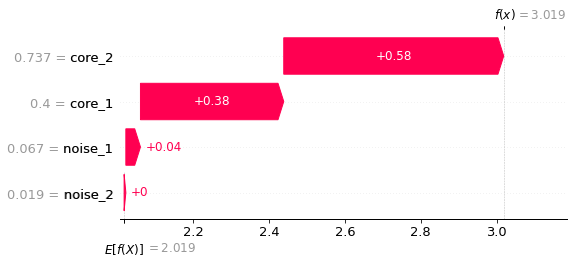

In [653]:
sh_test= to_sh_exp(stationary, exp_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

# ---------- Test - split costs matrix - negative and positive values

In [381]:
# test considering p_matrix generated from no_i no_ij difference

# get errors from accs
#err_no_i= get_error(p_pred_target, acc_no_i)
#err_no_ij= get_error(p_pred_target, acc_no_ij)

# get the probability matrix
p_matrix= get_p_matrix_dif(num_fts, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_2    0.200227
noise_1    0.200169
core_1     0.199714
core_2     0.199669
dtype: float64

In [382]:
p_matrix

array([[ 0.00000e+00, -1.44643e-03,  0.00000e+00,  0.00000e+00],
       [-1.08910e-03,  0.00000e+00,  4.99487e-05,  1.94013e-04],
       [-7.15256e-07, -3.08096e-04,  0.00000e+00,  0.00000e+00],
       [-7.15256e-07, -1.64032e-04,  0.00000e+00,  0.00000e+00]])

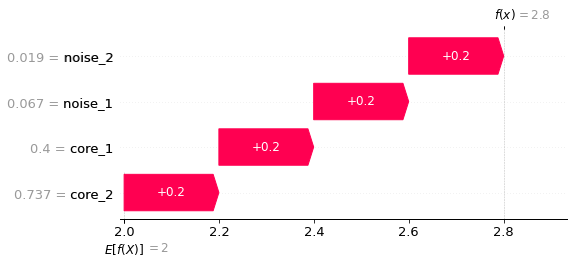

In [383]:
sh_test= to_sh_exp(stationary, exp_value, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

In [384]:
pos_p_matrix= np.zeros((num_fts, num_fts))
neg_p_matrix= np.zeros((num_fts, num_fts))

for i in range(num_fts):
    for j in range(num_fts):
        
        if (i!= j):
            if (p_matrix[i][j]< 0):
                neg_p_matrix[i][j]= p_matrix[i][j]
                pos_p_matrix[i][j]= 0
            else:
                neg_p_matrix[i][j]= 0
                pos_p_matrix[i][j]= p_matrix[i][j]
            
print(pos_p_matrix)
print("\n")
print(neg_p_matrix)

[[0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 0.00000e+00 4.99487e-05 1.94013e-04]
 [0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00]
 [0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00]]


[[ 0.00000e+00 -1.44643e-03  0.00000e+00  0.00000e+00]
 [-1.08910e-03  0.00000e+00  0.00000e+00  0.00000e+00]
 [-7.15256e-07 -3.08096e-04  0.00000e+00  0.00000e+00]
 [-7.15256e-07 -1.64032e-04  0.00000e+00  0.00000e+00]]


In [385]:
# get the stationary distribution positive
pos_stationary= p_matrix_to_stationary_dist(pos_p_matrix)

pos_ft_ranking= pd.Series(pos_stationary, index=train.columns).sort_values(ascending=False)
pos_ft_ranking

noise_2    0.323815
core_2     0.250000
noise_1    0.176185
core_1     0.125000
dtype: float64

In [386]:
# get the stationary distribution negative
neg_stationary= p_matrix_to_stationary_dist(np.abs(neg_p_matrix)) # note abs use

neg_ft_ranking= pd.Series(neg_stationary, index=train.columns).sort_values(ascending=False)
neg_ft_ranking

core_1     5.000000e-01
core_2     5.000000e-01
noise_1    4.163336e-17
noise_2   -1.387779e-17
dtype: float64

# Magnitude

In [572]:
# test considering p_matrix generated from no_i no_ij abs(difference)

# get the probability matrix
p_matrix= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.499820
core_1     0.408708
noise_2    0.072744
noise_1    0.018728
dtype: float64

In [573]:
p_matrix

array([[0.00000e+00, 1.44643e-03, 0.00000e+00, 0.00000e+00],
       [1.08910e-03, 0.00000e+00, 4.99487e-05, 1.94013e-04],
       [7.15256e-07, 3.08096e-04, 0.00000e+00, 0.00000e+00],
       [7.15256e-07, 1.64032e-04, 0.00000e+00, 0.00000e+00]])

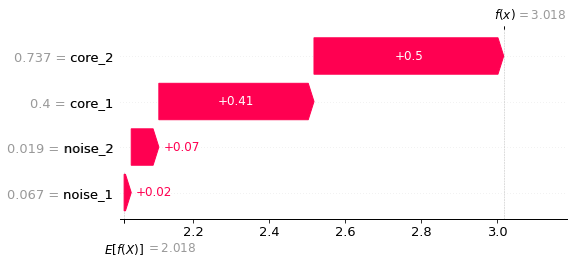

In [574]:
sh_test= to_sh_exp(stationary, proba_all, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

# Divergence

In [575]:
# test considering p_matrix generated from no_i no_ij divergence

# get the probability matrix
p_matrix= get_p_matrix_div(num_fts, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.500000
core_1     0.483635
noise_2    0.015348
noise_1    0.001017
dtype: float64

In [576]:
p_matrix

array([[0.00000e+00, 2.09215e-06, 0.00000e+00, 0.00000e+00],
       [1.18613e-06, 0.00000e+00, 2.49487e-09, 3.76411e-08],
       [5.11591e-13, 9.49234e-08, 0.00000e+00, 0.00000e+00],
       [5.11591e-13, 2.69065e-08, 0.00000e+00, 0.00000e+00]])

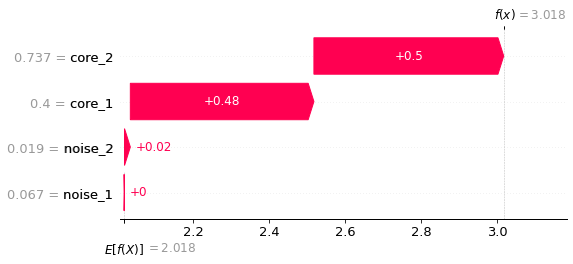

In [577]:
sh_test= to_sh_exp(stationary, proba_all, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

# Ratio

In [578]:
# test considering p_matrix generated from no_i no_ij ratio

# get the probability matrix
p_matrix= get_p_matrix_ratio(num_fts, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_2    0.250110
noise_1    0.250092
core_1     0.249951
core_2     0.249848
dtype: float64

In [579]:
p_matrix

array([[1.     , 0.99714, 1.     , 1.     ],
       [0.99784, 1.     , 1.0001 , 1.00038],
       [1.     , 0.99939, 1.     , 1.     ],
       [1.     , 0.99968, 1.     , 1.     ]])

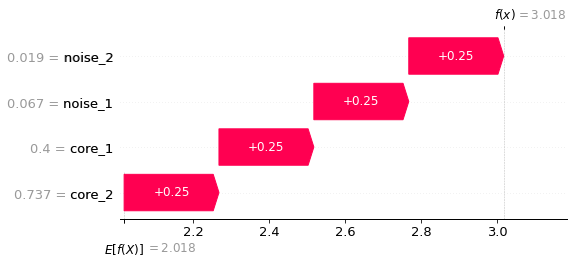

In [580]:
sh_test= to_sh_exp(stationary, proba_all, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

In [581]:
# test considering p_matrix generated from no_i no_ij ratio NEW VERSION

# get the probability matrix
p_matrix= get_p_matrix_ratio_v2(num_fts, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

noise_2    0.250110
noise_1    0.250092
core_1     0.249951
core_2     0.249848
dtype: float64

In [582]:
p_matrix

array([[0.25018, 0.24946, 0.25018, 0.25018],
       [0.24956, 0.2501 , 0.25013, 0.2502 ],
       [0.25004, 0.24989, 0.25004, 0.25004],
       [0.25002, 0.24994, 0.25002, 0.25002]])

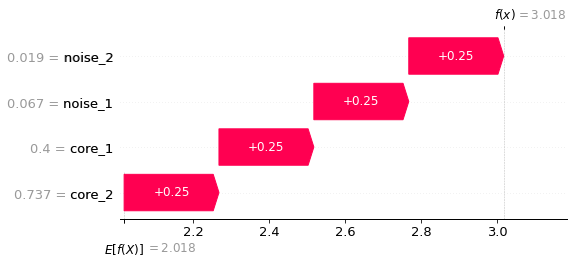

In [583]:
sh_test= to_sh_exp(stationary, proba_all, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

# ei eij p_matrix div

In [584]:
# test considering p_matrix generated from ei = fi - f0 and eij = fij - fi

e_i= get_dif_from_original(num_fts, exp_value, acc_no_i)

e_ij= get_dif_from_original(num_fts, exp_value, acc_no_ij)

# get the probability matrix
p_matrix= get_p_matrix_div(num_fts, e_i, e_ij)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.500000
core_1     0.483635
noise_2    0.015348
noise_1    0.001017
dtype: float64

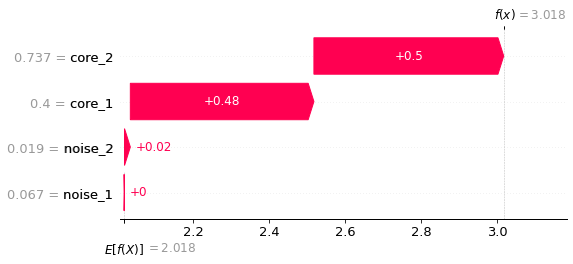

In [585]:
sh_test= to_sh_exp(stationary, proba_all, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

# Shapley values i and ij

In [655]:
# test considering p_matrix generated from shapley values i row and ij row

# get the first row shapley values to fi
sh_phi_i= get_p_vector_fi(num_fts, p_pred_target, acc_no_i)

# get the second row shapley values to fij
sh_phi_ij= get_p_matrix_fij(num_fts, p_pred_target, acc_no_i, acc_no_ij)

# get the probability matrix difference between fij and fi
p_matrix= get_sh_matrix(num_fts, sh_phi_i, sh_phi_ij, mag=True)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.579472
core_1     0.377480
noise_1    0.038484
noise_2    0.004564
dtype: float64

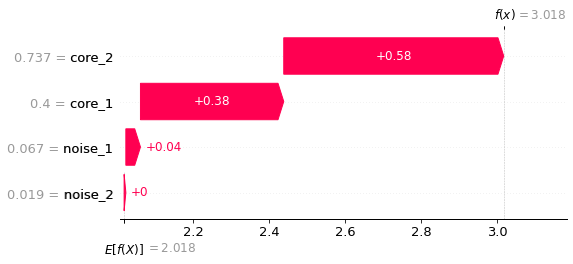

In [567]:
sh_test= to_sh_exp(stationary, proba_all, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

In [568]:
target_inst

,core_1,core_2,noise_1,noise_2
42,0.399874,0.736527,0.066727,0.019058


# Test using classes "baselines"

In [499]:
# Split the train dataset according its classes
lb_train_a= labels_train.loc[labels_train['target'] == 1]
lb_train_b= labels_train.loc[labels_train['target'] == 0]

train_a= train.loc[lb_train_a.index,:]
train_b= train.loc[lb_train_b.index,:]

In [500]:
# determine a baseline related to each class using the mean
base_a= replace_values(train_a, train_a.columns, num_type='mean')
base_b= replace_values(train_b, train_b.columns, num_type='mean')

lb_base_a= lb_train_a.iloc[0].to_frame().T
lb_base_b= lb_train_b.iloc[0].to_frame().T

print(lb_base_a)
print("Pred base_a sample", xgb_model.predict(base_a))
print("\n")
print(lb_base_b)
print("Pred base_b sample", xgb_model.predict(base_b))
print("\n")
print(target_labl)
print("Pred sample to explain", xgb_model.predict(target_inst))

     target
281     1.0
Pred base_a sample [1]


     target
906     0.0
Pred base_b sample [0]


    target
42     1.0
Pred sample to explain [1]


In [501]:
# get the model behavior after removing i (single ft) and ij (pair) for each baseline

a_no_i, a_no_ij= remove_and_gen_costs(xgb_model, num_fts, replace_ft, base_a, lb_base_a, 
                                      use_preds= True, verbose=True)

b_no_i, b_no_ij= remove_and_gen_costs(xgb_model, num_fts, replace_ft, base_b, lb_base_b, 
                                      use_preds= True, verbose=True)

--- 0.18 seconds ---
--- 0.15 seconds ---


In [502]:
# baseline - class a - target 1
# test considering p_matrix generated from no_i no_ij divergence

# get the probability matrix
a_p_matrix= get_p_matrix_div(num_fts, a_no_i, a_no_ij)

# get the stationary distribution
a_stationary= p_matrix_to_stationary_dist(a_p_matrix)

a_ft_ranking= pd.Series(a_stationary, index=train.columns).sort_values(ascending=False)
a_ft_ranking

core_2     5.000000e-01
core_1     5.000000e-01
noise_1    5.551115e-17
noise_2    5.551115e-17
dtype: float64

In [503]:
# baseline - class b - target 0
# test considering p_matrix generated from no_i no_ij divergence

# get the probability matrix
b_p_matrix= get_p_matrix_div(num_fts, b_no_i, b_no_ij)

# get the stationary distribution
b_stationary= p_matrix_to_stationary_dist(b_p_matrix)

b_ft_ranking= pd.Series(b_stationary, index=train.columns).sort_values(ascending=False)
b_ft_ranking

core_2     4.999995e-01
core_1     4.999478e-01
noise_1    5.267058e-05
noise_2    1.103599e-16
dtype: float64

In [504]:
# baseline - general mean - "neutral sample"
# test considering p_matrix generated from no_i no_ij divergence

# get the probability matrix
p_matrix= get_p_matrix_div(num_fts, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary= p_matrix_to_stationary_dist(p_matrix)

ft_ranking= pd.Series(stationary, index=train.columns).sort_values(ascending=False)
ft_ranking

core_2     0.500000
core_1     0.483635
noise_2    0.015348
noise_1    0.001017
dtype: float64

In [505]:
# Our sample under explanation (target_inst) is predicted to class 1, such as base_a prediction

# Then we determine ft_rank(class(target_inst)) 
#                   - ft_rank(class(base)!= class(target_inst)) 
#                   + ft_rank(class(base)== class(target_inst))

# That is, class(target_inst)==1 - class(base_b)==0 + class(base_a)==1
final_ft_ranking= stationary - b_stationary + a_stationary

final_ft_ranking= pd.Series(final_ft_ranking, index=train.columns).sort_values(ascending=False)
final_ft_ranking

core_2     0.500000
core_1     0.483687
noise_2    0.015348
noise_1    0.000965
dtype: float64

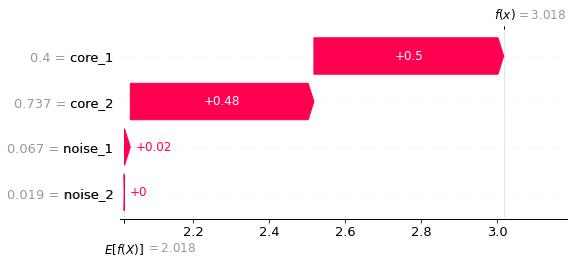

In [506]:
sh_test= to_sh_exp(final_ft_ranking, proba_all, np.asarray(target_inst)[0], target_inst.columns)

shap.plots.waterfall(sh_test)

# Tests using SHAP

ntree_limit is deprecated, use `iteration_range` or model slicing instead.


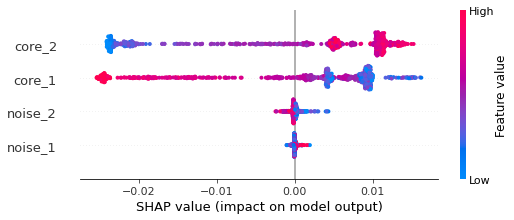

In [507]:
explainer= shap.Explainer(xgb_model)
shap_values= explainer(train)
shap.plots.beeswarm(shap_values)

In [508]:
shap.plots.force(shap_values[target_pos])

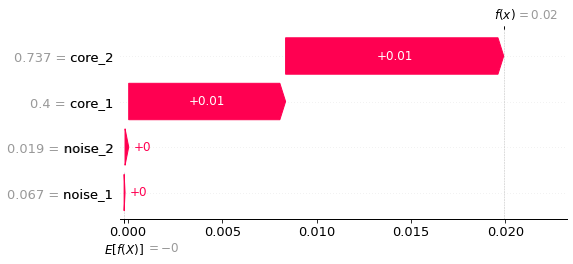

In [509]:
shap.plots.waterfall(shap_values[target_pos])

In [414]:
# tests using LIME

import lime
import lime.lime_tabular

explainer= lime.lime_tabular.LimeTabularExplainer(np.asarray(train), feature_names=np.asarray(x_syn.columns), 
                                                  class_names= np.asarray([0,1]), verbose=False, 
                                                  mode='classification', discretize_continuous=False)

In [415]:
exp= explainer.explain_instance(np.asarray(target_inst)[0], xgb_model.predict_proba, num_features=4, 
                                top_labels=1)

exp.show_in_notebook(show_table=True, show_all=True)

In [416]:
print('Element id: %d' % target_pos)
print('Probability(0 class) =', xgb_model.predict_proba(target_inst)[0,0])
print('True class: %s' % int(np.asarray(target_labl)[0]))

Element id: 1
Probability(0 class) = 0.4950214
True class: 1


# Feature Attribution using PageRank - methods

In [94]:
def run_lib_pr(graph_matrix, ft_names, iteration= 100, damping_factor= 0.85, tolerance= 1.0e-6):
    
    num_fts= graph_matrix.shape[0]
    
    D= nx.DiGraph()

    for i in range(num_fts):
        for j in range(num_fts):
            if (i!= j):
                D.add_weighted_edges_from([(ft_names[i],ft_names[j],graph_matrix[i,j])])
    
                
    pRank= pd.Series(nx.pagerank(D, max_iter=iteration, alpha=damping_factor, tol=tolerance))

    return pRank.sort_values(ascending=False)

In [95]:
# using my PR to compare results
def run_my_pr(graph_matrix, ft_names, iteration= 100, damping_factor= 0.95, tolerance= 1.0e-6):
    
    file_path= 'datasets/FAR_data.txt'
    
    num_fts= graph_matrix.shape[0]

    f= open(file_path, 'w')

    for i in range(num_fts):
        for j in range(num_fts):
            line= (str(int(i)) + ',' + str(int(j)) + ',' + str(graph_matrix[i,j]) + '\n')
            f.write(line)

    f.close()

    graph= gpr.init_graph(file_path)

    myPRank= pd.Series(pr.run_PageRank(graph, iteration=iteration, damping_factor=damping_factor, 
                                       tolerance=tolerance))
    myPRank= myPRank.sort_values(ascending=False)
    
    ids_names= ft_names[(myPRank.index).astype(int)]

    myPRank.index= ids_names

    return myPRank

# OLD --- Tests using the Titanic dataset ---

# Data loading and preprocessing

In [96]:
#!kaggle competitions download -c titanic

In [97]:
ds= zf.ZipFile('datasets/titanic.zip')

train_data= pd.read_csv(ds.open('train.csv'))
test_data= pd.read_csv(ds.open('test.csv'))

train_data.shape, test_data.shape

((891, 12), (418, 11))

In [ ]:
train_data.head()

In [ ]:
test_data.head()

In [ ]:
X_all= pd.concat([train_data[['PassengerId','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']],
                   test_data[['PassengerId','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]]).set_index('PassengerId')

y_train= train_data[['PassengerId','Survived']].set_index('PassengerId')['Survived']

X_all

In [ ]:
numeric_columns= ['Age','SibSp','Parch','Fare']
categor_columns= list(filter(lambda x:x not in numeric_columns,X_all.columns))

X_train= X_all.iloc[:len(train_data),:].copy()
X_test= X_all.iloc[len(train_data):].copy()

In [ ]:
# in this case we'll only use X_train df because X_test is not labeled

In [ ]:
X_train= pre_proc_fillna_num_fts(X_train,numeric_columns,num_type='median')

X_train= pre_proc_fillna_cat_fts(X_train,categor_columns,cat_type='mode')

X_train

In [ ]:
# one-hot encoding the qualitative features
X_train_ohe= pd.get_dummies(X_train,columns=categor_columns)

X_train_ohe.head()

In [ ]:
y_train.head()

In [ ]:
# normalize the numeric columns of dataframe with each value between 0 and 1
X_train= normalize_selected(X_train, numeric_columns)
X_train_ohe= normalize_selected(X_train_ohe, numeric_columns)

# ML model setup

In [ ]:
train, test, labels_train, labels_test= train_test_split(X_train_ohe,y_train,train_size=0.80,random_state=1234)
rf= sklearn.ensemble.RandomForestClassifier(n_estimators=500,n_jobs=2)

#train, test, labels_train, labels_test= train_test_split(X_train_ohe,y_train,train_size=0.80,random_state=1234)
#xgb_model= xgb.XGBRFClassifier(n_estimators=500,eval_metric='logloss',use_label_encoder=False)

#train, test, labels_train, labels_test= train_test_split(X_train,y_train,train_size=0.80,random_state=1234)
#cat_fts= [train.columns.to_list().index(col) for col in categor_columns]
#ctb_model= CatBoostClassifier(cat_features=cat_fts,silent=True)

# --- Run global modeling (no retraining) ---

In [ ]:
repeat_train= 1

num_fts= len(train.columns)

In [ ]:
# train the ML model and get the accuracy using the entire feature set
acc_all_fts= train_model_get_acc_mean(rf, train, test, labels_train, labels_test, repeat_train)

# rf is the model trained

acc_all_fts

In [ ]:
# values to "remove" (entire dataset)
replace_ft= replace_values(X_train_ohe, numeric_columns, num_type='mean', cat_type='median')

replace_ft

In [ ]:
# calculates "transition" costs removing columns from the feature set using a trained model

acc_no_i, acc_no_ij= remove_and_return_costs(rf, replace_ft, test, labels_test, True)

In [ ]:
#print(acc_no_i)
print(np.around(acc_no_i, decimals=3))
print("-----------------------------")
#print(acc_no_ij)
print(np.around(acc_no_ij, decimals=3))

In [ ]:
# get the probability matrix
p_matrix1= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)
p_matrix2= get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

#print(p_matrix1)
print(np.around(p_matrix1, decimals=3))
print("-----------------------------")
#print(p_matrix2)
print(np.around(p_matrix2, decimals=3))
print("-----------------------------")
#print(p_matrix3)
print(np.around(p_matrix3, decimals=3))
print("-----------------------------")
#print(p_matrix4)
print(np.around(p_matrix4, decimals=3))

In [ ]:
# get the stationary distribution
stationary_d1= p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= p_matrix_to_stationary_dist(p_matrix4)

print(stationary_d1)
print("-----------------------------")
print(stationary_d2)
print("-----------------------------")
print(stationary_d3)
print("-----------------------------")
print(stationary_d4)

In [ ]:
rp_list= {'Sex_male':'Sex','Sex_female':'Sex','Pclass_1':'Pclass','Pclass_2':'Pclass','Pclass_3':'Pclass',
          'Embarked_S':'Embarked','Embarked_Q':'Embarked','Embarked_C':'Embarked'}

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d1, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d2, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d2,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d3, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d4, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

# --- Run local modeling (k-NN version, no retraining) ---

In [ ]:
# the instance to be explained (from train dataset)
target_index= 1

target_inst= train.loc[train.index== target_index]
target_labl= labels_train.loc[labels_train.index== target_index]

In [ ]:
# calculates "transition" costs removing columns from a target instance using a trained model
# target instance is supported by neighb_size percent nearest neighbors of test dataset

acc_no_i, acc_no_ij= knn_remove_and_return_costs(rf, replace_ft, test, labels_test, target_inst, target_labl,
                                                 neighb_size= 0.5, verbose=True)

In [ ]:
print(acc_all_fts)
print("-----------------------------")
#print(acc_no_i)
print(np.around(acc_no_i, decimals=3))
print("-----------------------------")
#print(acc_no_ij)
print(np.around(acc_no_ij, decimals=3))

In [ ]:
# get the probability matrix
p_matrix1= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)
p_matrix2= get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

#print(p_matrix1)
print(np.around(p_matrix1, decimals=3))
print("-----------------------------")
#print(p_matrix2)
print(np.around(p_matrix2, decimals=3))
print("-----------------------------")
#print(p_matrix3)
print(np.around(p_matrix3, decimals=3))
print("-----------------------------")
#print(p_matrix4)
print(np.around(p_matrix4, decimals=3))

In [ ]:
# get the stationary distribution
stationary_d1= p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= p_matrix_to_stationary_dist(p_matrix4)

print(stationary_d1)
print("-----------------------------")
print(stationary_d2)
print("-----------------------------")
print(stationary_d3)
print("-----------------------------")
print(stationary_d4)

In [ ]:
rp_list= {'Sex_male':'Sex','Sex_female':'Sex','Pclass_1':'Pclass','Pclass_2':'Pclass','Pclass_3':'Pclass',
          'Embarked_S':'Embarked','Embarked_Q':'Embarked','Embarked_C':'Embarked'}

In [ ]:
# TARGET INSTANCE TO EXPLAIN ITS FEATURES

X_all.loc[X_all.index== target_index]

In [ ]:
target_label

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d1, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d2, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d2,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d3, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d4, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

# --- Run PageRank approach (k-NN local version, no retraining) ---

In [ ]:
print(acc_all_fts)
print("-----------------------------")
#print(acc_no_i)
print(np.around(acc_no_i, decimals=3))
print("-----------------------------")
#print(acc_no_ij)
print(np.around(acc_no_ij, decimals=3))

In [ ]:
# get the probability matrix
p_matrix1= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)
p_matrix2= get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# finding the stationary distribution
st_matrix1= p_matrix_to_row_stochastic_matrix(p_matrix1)
st_matrix2= p_matrix_to_row_stochastic_matrix(p_matrix2)
st_matrix3= p_matrix_to_row_stochastic_matrix(p_matrix3)
st_matrix4= p_matrix_to_row_stochastic_matrix(p_matrix4)

In [ ]:
run_lib_pr(st_matrix1, X_train_ohe.columns)

In [ ]:
run_lib_pr(st_matrix2, X_train_ohe.columns)

In [ ]:
run_lib_pr(st_matrix3, X_train_ohe.columns)

In [ ]:
run_lib_pr(st_matrix4, X_train_ohe.columns)

In [ ]:
run_my_pr(st_matrix1, X_train_ohe.columns)

In [ ]:
run_my_pr(st_matrix2, X_train_ohe.columns)

In [ ]:
run_my_pr(st_matrix3, X_train_ohe.columns)

In [ ]:
run_my_pr(st_matrix4, X_train_ohe.columns)

# --- Run local modeling (k-Fold version, no retraining) ---

In [ ]:
# calculates "transition" costs removing columns from a target instance using a trained model
# target instance is supported by neighb_size percent nearest neighbors of test dataset applied in a kfolding way

acc_no_i, acc_no_ij= knnfold_remove_and_return_costs(rf, replace_ft, test, labels_test, 
                                                     target_inst, target_labl, neighb_size= 0.5, 
                                                     k_folds=10, verbose=True)

In [ ]:
print(acc_all_fts)
print("-----------------------------")
#print(acc_no_i)
print(np.around(acc_no_i, decimals=3))
print("-----------------------------")
#print(acc_no_ij)
print(np.around(acc_no_ij, decimals=3))

In [ ]:
# get the probability matrix
p_matrix1= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)
p_matrix2= get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

#print(p_matrix1)
print(np.around(p_matrix1, decimals=3))
print("-----------------------------")
#print(p_matrix2)
print(np.around(p_matrix2, decimals=3))
print("-----------------------------")
#print(p_matrix3)
print(np.around(p_matrix3, decimals=3))
print("-----------------------------")
#print(p_matrix4)
print(np.around(p_matrix4, decimals=3))

In [ ]:
# get the stationary distribution
stationary_d1= p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= p_matrix_to_stationary_dist(p_matrix4)

print(stationary_d1)
print("-----------------------------")
print(stationary_d2)
print("-----------------------------")
print(stationary_d3)
print("-----------------------------")
print(stationary_d4)

In [ ]:
rp_list= {'Sex_male':'Sex','Sex_female':'Sex','Pclass_1':'Pclass','Pclass_2':'Pclass','Pclass_3':'Pclass',
          'Embarked_S':'Embarked','Embarked_Q':'Embarked','Embarked_C':'Embarked'}

In [ ]:
# TARGET INSTANCE TO EXPLAIN ITS FEATURES

X_all.loc[X_all.index== target_index]

In [ ]:
target_label

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d1, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d2, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d2,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d3, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d4, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

# --- Global version with retraining ---

In [ ]:
repeat_train= 5

acc_all_fts= train_model_get_acc_mean(rf, train, test, labels_train, labels_test, repeat_train)

acc_no_i, acc_no_ij= remove_and_retrain(rf, replace_ft, train, test, labels_train, labels_test,
                                        repeat_train, verbose=True)

In [ ]:
# get the probability matrix
p_matrix1= get_p_matrix_mag(num_fts, acc_no_i, acc_no_ij)
p_matrix2= get_p_matrix_v2(num_fts, acc_no_i, acc_no_ij)
p_matrix3= get_p_matrix_v3(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)
p_matrix4= get_p_matrix_v4(num_fts, acc_all_fts, acc_no_i, acc_no_i, acc_no_ij)

# get the stationary distribution
stationary_d1= p_matrix_to_stationary_dist(p_matrix1)
stationary_d2= p_matrix_to_stationary_dist(p_matrix2)
stationary_d3= p_matrix_to_stationary_dist(p_matrix3)
stationary_d4= p_matrix_to_stationary_dist(p_matrix4)

In [ ]:
rp_list= {'Sex_male':'Sex','Sex_female':'Sex','Pclass_1':'Pclass','Pclass_2':'Pclass','Pclass_3':'Pclass',
          'Embarked_S':'Embarked','Embarked_Q':'Embarked','Embarked_C':'Embarked'}

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d1, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d1
ft_ranking= pd.Series(stationary_d2, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d2,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d3, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

In [ ]:
# feature importance ranking stationary_d2
ft_ranking= pd.Series(stationary_d4, index=X_train_ohe.columns).sort_values(ascending=False)
ft_ranking

In [ ]:
ft_importance_df(stationary_d1,X_train_ohe.columns,rp_list)

# Misc

In [ ]:
eigval, eigvec= eigs(st_matrix3.T, k=1, which='LM')
eigval

In [ ]:
f= open('datasets/FAR_data.txt', 'w')

for i in range(num_fts):
    for j in range(num_fts):
        line= (str(i) + ',' + str(j) + ',' + str(p_matrix1[i][j]) + '\n')
        f.write(line)
        
f.close()